# Transformer 구조의 챗봇을 GPT-1 구조로 변경

## 변경 사항

### 1. 입력 데이터 형식 변경

기존에는 질문과 답변을 encoder 입력과 decoder 입력으로 분리했습니다.

GPT 방식에서는 다음과 같이 하나의 sequence로 연결합니다.

```text
<s> 질문 $ 답변 <e>
```

- `<s>`: 시작 토큰
- `$`: 질문과 답변을 구분하는 토큰
- `<e>`: 종료 토큰

### 2. Encoder 제거

GPT는 encoder-decoder 구조가 아닌 decoder-only 구조를 사용합니다.
따라서 기존 Transformer encoder와 EncoderLayer를 제거했습니다.

### 3. Cross-attention 제거

각 GPT 블록에서는 decoder self-attention만 사용합니다.
Encoder 출력과 decoder 사이의 cross-attention은 제거했습니다.

```text
Token Embedding + Position Embedding
                |
       Causal Self-Attention
                |
          GELU Feed Forward
                |
          Transformer Block 반복
                |
       Vocabulary Logits 출력
```

### 4. Causal Language Modeling

각 위치에서 미래 토큰을 참조하지 않고 다음 토큰을 예측하도록 causal mask를 적용했습니다.

입력과 target은 한 칸 이동하여 구성합니다.

```text
input : <s> 질문 $ 답변
 target: 질문 $ 답변 <e>
```

답변 생성에 집중하기 위해 질문과 `$`에 해당하는 target은 loss에서 제외하고, 답변 토큰과 `<e>`만 loss 계산에 사용합니다.

### 5. GPT 구성 요소 변경

- Sinusoidal positional encoding을 학습 가능한 position embedding으로 변경
- Feed-forward 활성화 함수를 `ReLU`에서 `GELU`로 변경
- `model(enc_input, dec_input)`을 `model(input_ids)`로 변경
- Padding mask와 causal mask를 결합

### 6. 질의응답 추론

질문 뒤에 `$`를 붙여 GPT prompt를 만든 다음, 답변을 한 토큰씩 autoregressive하게 생성합니다.

```text
<s> 질문 $ 답변 토큰 1 답변 토큰 2 ... <e>
```

> 참고:
질의응답 데이터셋을 사용하여 질의응답에만 특화된 학습 방식을 사용합니다.

In [1]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

[colab-compat] torch.load weights_only=False 패치 적용


In [2]:
!pip install sentencepiece

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# 최대 시퀀스 길이(전처리 max_length와 동일). 포지셔널 임베딩의 position 인자로 사용합니다.
MAX_LENGTH = 26

# Data

## Data Preparation

In [4]:
import pandas as pd

# ChatbotData.csv 다운로드 URL
url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
csv_filename = 'ChatbotData.csv'

# 이미 파일이 없는 경우에만 다운로드
if not os.path.exists(csv_filename):
    print(f"Downloading {csv_filename} ...")
    urllib.request.urlretrieve(url, csv_filename)
    print("Download complete.")

# CSV 파일 불러오기
data = pd.read_csv(csv_filename)

print("데이터 크기:", data.shape)
data.head()

Download complete.
데이터 크기: (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [5]:
# label 컬럼은 제외
data = data.drop(['label'], axis=1)

## EDA

In [6]:
print('========== data.shape ==========')
print(data.shape)
print('========== data.info() ==========')
print(data.info())

========== data.shape ==========
(11823, 2)
========== data.info() ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
dtypes: object(2)
memory usage: 184.9+ KB
None


## Data Preprocessing

In [7]:
# 공백 제거
data['Q'] = data['Q'].str.strip()
data['A'] = data['A'].str.strip()

# 연속된 공백 하나로 변경
data['Q'] = data['Q'].str.replace(r'\s+', ' ', regex=True)
data['A'] = data['A'].str.replace(r'\s+', ' ', regex=True)

# 중복 제거
data = data.drop_duplicates()

# index 초기화
data = data.reset_index(drop=True)

print(data.shape)
display(data.sample(10))

(11750, 2)


,Q,A
7552,이별한지 두달이 넘고 얼굴 안본지 한달이 넘은,기억의 저편으로 남겨두세요.
6158,뜬금 시간을 가지자고 해서,의아하셨겠어요.
2677,스터디 카페 좋다,공부하러 왔나봐요.
2205,비밀 지킬 수 있을까,세상에 비밀은 없어요.
1924,반장이라서 힘들어,아무래도 책임이 뒤따르니까요.
5676,그만 울어야지,툭툭 털고 일어나세요.
2463,섬유유연제 향 좋다,향이 많은 걸 말해주죠.
4435,참아야 하나,가끔 표출하는 것도 좋아요.
4773,콜록콜록,건강에 유의하세요.
10769,용기내볼까?,용기내보는 것도 좋을 것 같아요.


In [8]:
questions = data['Q'].values
answers = data['A'].values

# Tokenizer

## Corpus for SentencePiece Training

In [9]:
corpus_file = "clean_corpus.txt"

with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in zip(questions, answers):
        f.write(q + "\n")
        f.write(a + "\n")

## SentencePiece training

In [10]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_chatbot",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    user_defined_symbols=["$"],  # 변경: GPT의 문서/질문과 답변을 구분하는 독립 토큰
    bos_id=1,      # <s>
    eos_id=2,      # </s>
    pad_id=0,      # <pad>
    unk_id=3       # <unk>
)

True

In [11]:
# SentencePiece 테스트

sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

test_sentences = [
    "오늘 기분이 어때?",
    "너는 누구야?",
    "밥 먹었어?",
    "요즘 너무 힘들어.",
    "안녕하세요.",
    "고마워!"
]

for sentence in test_sentences:
    tokens = sp.encode(sentence, out_type=str)
    ids = sp.encode(sentence, out_type=int)
    decoded = sp.decode(ids)

    print("=" * 50)
    print("원문 :", sentence)
    print("토큰 :", tokens)
    print("ID   :", ids)
    print("복원 :", decoded)

원문 : 오늘 기분이 어때?
토큰 : ['▁오늘', '▁기분이', '▁어때', '?']
ID   : [126, 930, 644, 6789]
복원 : 오늘 기분이 어때?
원문 : 너는 누구야?
토큰 : ['▁너는', '▁누구', '야', '?']
ID   : [3629, 484, 6811, 6789]
복원 : 너는 누구야?
원문 : 밥 먹었어?
토큰 : ['▁밥', '▁먹었어', '?']
ID   : [732, 5038, 6789]
복원 : 밥 먹었어?
원문 : 요즘 너무 힘들어.
토큰 : ['▁요즘', '▁너무', '▁힘들어', '.']
ID   : [694, 55, 418, 6760]
복원 : 요즘 너무 힘들어.
원문 : 안녕하세요.
토큰 : ['▁안녕하세요', '.']
ID   : [4586, 6760]
복원 : 안녕하세요.
원문 : 고마워!
토큰 : ['▁고마워', '!']
ID   : [3745, 6910]
복원 : 고마워!


In [12]:
print("PAD:", sp.pad_id())
print("BOS:", sp.bos_id())
print("EOS:", sp.eos_id())
print("UNK:", sp.unk_id())

PAD: 0
BOS: 1
EOS: 2
UNK: 3


## Determine max_length based on token length
- 최종적으로 26으로 선택

In [13]:
sequence_lengths = []

for q, a in zip(questions, answers):
    # 변경: GPT에서는 질문과 답변을 하나의 sequence로 연결해 길이를 계산한다.
    q_ids = sp.encode(q, out_type=int)
    a_ids = sp.encode(a, out_type=int)
    sequence_lengths.append(len(q_ids) + len(a_ids) + 3)  # BOS, '$', EOS

sequence_lengths = np.array(sequence_lengths)

print("GPT sequence")
print("평균:", sequence_lengths.mean())
print("최대:", sequence_lengths.max())
print("95%:", np.percentile(sequence_lengths, 95))
print("99%:", np.percentile(sequence_lengths, 99))

GPT sequence
평균: 14.214893617021277
최대: 43
95%: 21.0
99%: 26.0


In [14]:
for max_length in [20, 26, 30, 35, 40]:
    # 변경: 질문과 답변 각각이 아니라 결합된 GPT sequence 길이로 제거 비율을 계산한다.
    removed = sum(
        len(sp.encode(q, out_type=int))
        + len(sp.encode(a, out_type=int))
        + 3 > max_length
        for q, a in zip(questions, answers)
    )

    print(
        f"max_length={max_length}: "
        f"{removed}개 제거 "
        f"({removed / len(questions) * 100:.2f}%)"
    )

max_length=20: 777개 제거 (6.61%)
max_length=26: 81개 제거 (0.69%)
max_length=30: 14개 제거 (0.12%)
max_length=35: 3개 제거 (0.03%)
max_length=40: 2개 제거 (0.02%)


# Dataset, Dataloader

## Dataset

- 질문과 답변을 하나의 sequence로 연결하여 학습 데이터 생성
- 데이터 형태를 `[BOS] + 질문 + [$] + 답변 + [EOS]`로 구성
- `input_ids`와 `target`을 한 칸 shift하여 다음 토큰 예측 학습이 가능하도록 구성
- 질문과 구분자($) 부분의 `target`을 `PAD`로 처리하여 답변 부분에 대해서만 Loss가 계산 되도록 구성
- 최대 길이에 맞게 padding하여 배치 학습이 가능하도록 구성

In [15]:
class ChatbotDataset(Dataset):
    def __init__(self, questions, answers, sp, delimiter_id, max_length=26):
        super().__init__()

        self.sp = sp
        self.delimiter_id = delimiter_id
        self.max_length = max_length
        self.data = []

        bos_id = sp.bos_id()
        eos_id = sp.eos_id()
        pad_id = sp.pad_id()

        for q_text, a_text in zip(questions, answers):
            # 변경: GPT는 질문과 답변을 encoder/decoder 입력으로 분리하지 않고
            # 하나의 autoregressive sequence로 연결한다.
            q_ids = sp.encode(q_text, out_type=int)
            a_ids = sp.encode(a_text, out_type=int)
            sequence = [bos_id] + q_ids + [delimiter_id] + a_ids + [eos_id]

            if len(sequence) > max_length:
                continue

            # 변경: 다음 토큰 예측을 위해 input과 target을 한 칸 shift한다.
            input_ids = sequence[:-1]
            target = sequence[1:]

            # 변경: 질문과 구분자 자체는 답변 생성 loss에서 제외한다.(pad_id로 대체)
            answer_start = len(q_ids) + 1  # input sequence에서 '$' 다음 위치
            target[:answer_start] = [pad_id] * answer_start

            # Padding
            input_ids += [pad_id] * (max_length - len(input_ids))
            target += [pad_id] * (max_length - len(target))

            self.data.append({
                "input_ids": input_ids,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (
            torch.tensor(sample["input_ids"], dtype=torch.long),
            torch.tensor(sample["target"], dtype=torch.long)
        )


# 변경: '$'를 SentencePiece에서 독립적인 GPT 구분자 토큰으로 사용한다.
delimiter_id = sp.piece_to_id("$")
if delimiter_id < 0:
    raise ValueError("'$' 토큰이 tokenizer vocabulary에 없습니다. SentencePiece를 다시 학습하세요.")

In [16]:
# 변경: 질문/답변을 분리하지 않고 하나의 GPT 학습 sequence를 만든다.
dataset = ChatbotDataset(
    questions,
    answers,
    sp,
    delimiter_id=delimiter_id,
    max_length=MAX_LENGTH
)

print("Dataset size:", len(dataset))

Dataset size: 11669


In [17]:
input_ids, target = dataset[0]

# 변경: encoder input/decoder input 대신 GPT의 단일 input sequence를 확인한다.
print("GPT input tokens:")
print([
    sp.id_to_piece(x)
    for x in input_ids.tolist()
    if x != sp.pad_id()
])

print("\nTarget tokens:")
print([
    sp.id_to_piece(x)
    for x in target.tolist()
    if x != sp.pad_id()
])

GPT input tokens:
['<s>', '▁12', '시', '▁땡', '!', '$', '▁하루가', '▁또', '▁가네요', '.']

Target tokens:
['▁하루가', '▁또', '▁가네요', '.', '</s>']


In [18]:
# 변경: GPT에서는 input_ids와 target의 padding만 확인한다.
print("Input PAD:", (input_ids == sp.pad_id()).sum().item())
print("Target PAD:", (target == sp.pad_id()).sum().item())

Input PAD: 16
Target PAD: 21


## Dataloader

In [19]:
# 변경: dataloader가 (input_ids, target) 두 항목만 반환한다.
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for input_ids, target in dataloader:
    print(input_ids.size())
    print(target.size())
    break

torch.Size([32, 26])
torch.Size([32, 26])


# Model structure

                  ChatbotDataset
                       ↓
                    input_ids
                       ↓
                    GPTModel
                       ↓
                ┌──────────────┐
                │ GPTEmbeddings│
                └──────┬───────┘
                       ↓
                Token + Position
                   Embedding
                       ↓
              ┌─────────────────┐
              │    GPTBlock     │
              │                 │
              │ MultiHead       │
              │ Attention       │
              │      ↓          │
              │ Scaled Dot      │
              │ Product         │
              │      ↓          │
              │ Feed Forward    │
              └────────┬────────┘
                       │
                       ↓
                  GPTBlock × N
                       ↓
                 Final LayerNorm
                       ↓
                    LM Head
                       ↓
              Vocabulary Logits
                       ↓
             Next Token Prediction

## Positional Embedding

- 입력된 토큰을 Token Embedding을 통해 `d_model` 차원의 벡터로 변환
- 각 토큰의 위치 정보를 **학습 가능한** Position Embedding으로 추가
- Token Embedding에 `√d_model`을 곱해 값의 크기를 조정
- Token Embedding + Position Embedding을 더하여 토큰의 의미와 위치 정보를 함께 표현
- Dropout을 적용하여 과적합을 방지

In [20]:
class GPTEmbeddings(nn.Module):
    def __init__(self, vocab_size, max_length, d_model, dropout=0.1):
        super().__init__()
        # 변경: GPT-1은 sinusoidal encoding 대신 학습 가능한 token/position embedding을 사용한다.
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        positions = torch.arange(     # 각 토큰의 위치 번호 [0, 1, 2, ...]
            input_ids.size(1), device=input_ids.device
        ).unsqueeze(0)
        x = self.token_embedding(input_ids) * math.sqrt(self.token_embedding.embedding_dim)
        x = x + self.position_embedding(positions)
        return self.dropout(x)

## Scaled Dot Product Attention

GPT의 Self-Attention에서 각 토큰이 다른 토큰을 얼마나 참고할지 계산하는 함수

- `Q(Query)`와 `K(Key)`의 내적을 통해 **토큰 간 유사도(Attention Score)** 계산
- `√depth`로 나누어 Score의 크기를 조정 (**Scaling**)
- `mask`가 있으면 특정 위치를 `-1e9`로 만들어 **Attention 대상에서 제외**
- `Softmax`를 적용하여 각 토큰이 다른 토큰을 얼마나 참고할지 나타내는 **Attention Weight** 생성
- Attention Weight와 `V(Value)`를 곱하여 최종 **Attention Output** 생성

In [21]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 마스크가 주어졌다면 아주 작은 값을 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

## Multi Head Attention

* 입력을 `Q(Query)`, `K(Key)`, `V(Value)`로 각각 Linear 변환
* `d_model`을 여러 개의 Head로 분할하여 여러 관점에서 Attention을 계산
* 각 Head에서 `Scaled Dot-Product Attention`을 수행
* 계산된 여러 Head의 결과를 다시 하나의 벡터로 결합(Concat)
* 마지막 `Linear` layer를 통해 최종 Attention 출력 생성


### 핵심

`d_model=768`, `num_heads=12`라면:

```text
768 ÷ 12 = 64
```

따라서 하나의 768차원 표현을 **12개의 Head × 64차원**으로 나누어 각각 Attention을 수행

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)   # 각 Head에서 얻은 정보를 하나의 새로운 표현으로 섞어주는 역할

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output

## GPT decoder-only block
- Causal self-attention
- Feed Forward Neural Network
- No encoder-decoder cross-attention

```
입력 x
  │
  ↓
Causal Self-Attention
  │
  ↓
Residual + LayerNorm
  │
  ↓
Feed Forward Network (FFN)
  │
  ↓
Residual + LayerNorm
  │
  ↓
출력
```

In [23]:
class GPTBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()

        # 변경: GPT 블록에는 decoder self-attention만 있고 cross-attention은 없다.
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 변경: GPT-1의 FFN 활성화 함수는 GELU를 사용한다.
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None):
        # 변경: 미래 토큰을 보지 못하도록 causal self-attention만 적용한다.
        attention = self.self_mha(x, x, x, mask=causal_mask)   # x를 Q, K, V로 사용(self attention)
        x = self.norm1(x + self.dropout(attention))

        feed_forward = self.ffn(x)
        x = self.norm2(x + self.dropout(feed_forward))
        return x

```
input_ids
    │
    ↓
GPTEmbeddings
    │
    ↓
GPTBlock × num_layers
    │
    ↓
Final LayerNorm
    │
    ↓
LM Head
    │
    ↓
Vocabulary logits
```

In [24]:
class GPTModel(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 max_length,
                 pad_id,
                 dropout=0.1):
        super().__init__()
        self.pad_id = pad_id
        self.embeddings = GPTEmbeddings(
            vocab_size=vocab_size,
            max_length=max_length,
            d_model=d_model,
            dropout=dropout
        )
        self.blocks = nn.ModuleList([
            GPTBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids):
        # 변경: encoder 입력과 decoder 입력을 나누지 않고 단일 input_ids만 받는다.
        seq_len = input_ids.size(1)
        device = input_ids.device

        # 변경: 각 위치가 미래 위치를 참조하지 못하도록 causal mask를 만든다.
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device),
            diagonal=1
        ).bool().unsqueeze(0).unsqueeze(0)

        # 변경: padding 위치도 attention에서 제외한다.
        padding_mask = input_ids.eq(self.pad_id).unsqueeze(1).unsqueeze(1)
        attention_mask = causal_mask | padding_mask

        x = self.embeddings(input_ids)
        for block in self.blocks:
            x = block(x, attention_mask)

        # 변경: 모든 위치에서 다음 토큰 vocabulary logits를 출력한다.
        return self.lm_head(self.final_norm(x))

## Model Definition

In [25]:
# 변경: 기존 encoder-decoder Transformer 대신 GPT decoder-only 모델을 생성한다.
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1
VOCAB_SIZE = sp.get_piece_size()

model = GPTModel(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    ff_dim=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_length=MAX_LENGTH,
    pad_id=sp.pad_id(),
    dropout=DROPOUT
)

print(model)

GPTModel(
  (embeddings): GPTEmbeddings(
    (token_embedding): Embedding(8000, 256)
    (position_embedding): Embedding(26, 256)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-1): 2 x GPTBlock(
      (self_mha): MultiHeadAttention(
        (query_dense): Linear(in_features=256, out_features=256, bias=True)
        (key_dense): Linear(in_features=256, out_features=256, bias=True)
        (value_dense): Linear(in_features=256, out_features=256, bias=True)
        (out_dense): Linear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm((2

# Model configuration

## Loss function

In [34]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

## Custom Learning rate Scheduling

학습 초반에는 Learning Rate를 점진적으로 증가시키고(Warmup) 이후에는 점차 감소

In [35]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

## Optimizer

In [36]:
# LambdaLR은 base_lr × lambda 로 곱하므로, get_lr_lambda 공식값을 그대로
# 실제 학습률로 쓰려면 base_lr=1.0 으로 두어야 합니다. (기본값 0.001이면 1/1000 스케일)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)   # PAD는 loss에서 제외
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()   # 정확하게 예측한 토큰 수 / PAD를 제외한 전체 토큰 수
    return acc.item()

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

# Training

In [38]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()

    # 변경: encoder/decoder 세 입력 대신 GPT input_ids와 shifted target을 받는다.
    input_ids, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 변경: GPT는 하나의 sequence에서 모든 위치의 다음 토큰 logits를 계산한다.
    logits = model(input_ids)

    loss = loss_function(
        logits.reshape(-1, logits.size(-1)),
        target.reshape(-1)
    )

    loss.backward()
    optimizer.step()

    accuracy = accuracy_function(
        logits,
        target,
        pad_id=sp.pad_id()
    )

    return loss.item(), accuracy

In [39]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):

        total_loss = 0
        total_acc = 0

        for step, batch in enumerate(dataloader):

            loss, acc = train_step(
                model,
                batch,
                optimizer,
                loss_function,
                device
            )

            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(
                    f"[Epoch {epoch+1}, Step {step}] "
                    f"Loss: {loss:.4f}, "
                    f"Acc: {acc:.4f}"
                )

            # 현재 scheduler는 batch 단위 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        # epoch 결과 저장
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        print(
            f"Epoch {epoch+1} Completed - "
            f"Avg Loss: {avg_loss:.4f}, "
            f"Avg Acc: {avg_acc:.4f}"
        )

    return loss_history, acc_history

In [40]:
%%time

loss_history, acc_history = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,
    device=device
)

[Epoch 1, Step 0] Loss: 9.1138, Acc: 0.0000
[Epoch 1, Step 100] Loss: 8.3766, Acc: 0.1368
[Epoch 1, Step 200] Loss: 6.8772, Acc: 0.2793
[Epoch 1, Step 300] Loss: 6.3312, Acc: 0.2780
Epoch 1 Completed - Avg Loss: 7.3344, Avg Acc: 0.2094
[Epoch 2, Step 0] Loss: 6.0328, Acc: 0.3048
[Epoch 2, Step 100] Loss: 5.7655, Acc: 0.2850
[Epoch 2, Step 200] Loss: 5.9744, Acc: 0.2747
[Epoch 2, Step 300] Loss: 5.2821, Acc: 0.3148
Epoch 2 Completed - Avg Loss: 5.7046, Avg Acc: 0.3024
[Epoch 3, Step 0] Loss: 5.2745, Acc: 0.3333
[Epoch 3, Step 100] Loss: 5.2114, Acc: 0.3133
[Epoch 3, Step 200] Loss: 5.1277, Acc: 0.3235
[Epoch 3, Step 300] Loss: 5.0543, Acc: 0.3289
Epoch 3 Completed - Avg Loss: 5.1991, Avg Acc: 0.3191
[Epoch 4, Step 0] Loss: 4.8096, Acc: 0.3317
[Epoch 4, Step 100] Loss: 5.0118, Acc: 0.2939
[Epoch 4, Step 200] Loss: 4.7509, Acc: 0.3467
[Epoch 4, Step 300] Loss: 4.8139, Acc: 0.3423
Epoch 4 Completed - Avg Loss: 4.7352, Avg Acc: 0.3412
[Epoch 5, Step 0] Loss: 4.2450, Acc: 0.3493
[Epoch 5, St

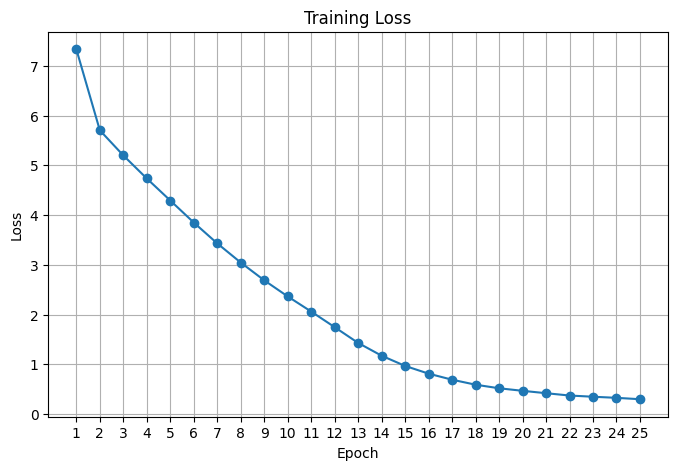

In [41]:
# loss rate 시각화

epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.xticks(epochs)
plt.grid(True)
plt.show()

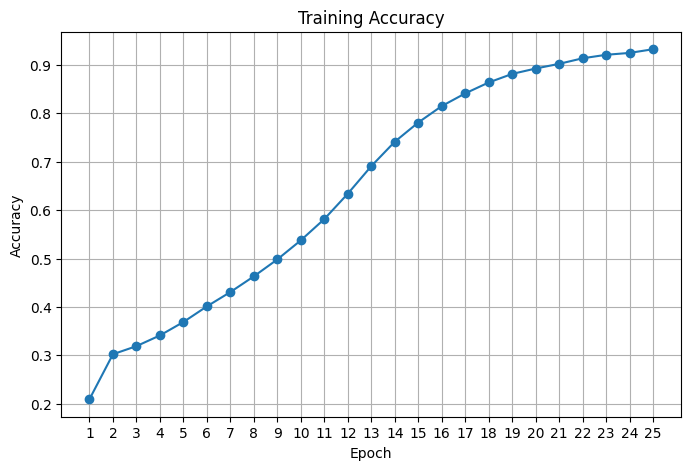

In [42]:
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.xticks(epochs)
plt.grid(True)
plt.show()

# Test

In [43]:
def decoder_inference(model, sentence, tokenizer, delimiter_id, max_length=20, device='cpu'):
    bos_id = tokenizer.bos_id()
    eos_id = tokenizer.eos_id()

    sentence = ' '.join(sentence.strip().split())
    question_ids = tokenizer.encode(sentence, out_type=int)

    # 변경: encoder 입력과 decoder 시작 입력을 나누지 않고 GPT prompt를 구성한다.
    prompt_ids = [bos_id] + question_ids + [delimiter_id]
    if len(prompt_ids) >= max_length:
        prompt_ids = prompt_ids[:max_length - 1] + [delimiter_id]

    input_ids = torch.tensor(
        [prompt_ids], dtype=torch.long, device=device
    )
    prompt_length = input_ids.size(1)

    model.eval()
    with torch.no_grad():
        for _ in range(max_length - prompt_length):
            # 변경: 현재까지의 sequence로 다음 토큰 하나를 autoregressive하게 예측한다.
            logits = model(input_ids)
            next_token = torch.argmax(logits[:, -1, :], dim=-1)
            input_ids = torch.cat(
                [input_ids, next_token.unsqueeze(1)], dim=1
            )

            if next_token.item() == eos_id:
                break

    # 변경: prompt(질문과 '$')를 제외하고 생성된 답변 토큰만 복원한다.
    answer_ids = input_ids[0, prompt_length:].tolist()
    if eos_id in answer_ids:
        answer_ids = answer_ids[:answer_ids.index(eos_id)]

    return tokenizer.decode(answer_ids)

In [44]:
def sentence_generation(model, sentence, tokenizer, delimiter_id, device='cpu'):
    # 변경: GPT는 질문 prompt 뒤에 답변을 autoregressive하게 생성한다.
    predicted_sentence = decoder_inference(
        model,
        sentence,
        tokenizer,
        delimiter_id=delimiter_id,
        max_length=MAX_LENGTH,
        device=device
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)

    return predicted_sentence

In [45]:
# 새로운 데이터로 테스트

test_sentences = [
    "오늘 너무 힘들어.",
    "나랑 영화 보러 갈래?",
    "요즘 기분이 별로야.",
    "너는 어떤 음식을 좋아해?",
    "오늘 날씨가 정말 좋네."
]

for sentence in test_sentences:
    print("=" * 50)

    sentence_generation(
        model,
        sentence,
        sp,
        delimiter_id=delimiter_id,
        device=device
    )

입력 : 오늘 너무 힘들어.
출력 : 고생 많았어요.
입력 : 나랑 영화 보러 갈래?
출력 : 저도 영화 보여주세요.
입력 : 요즘 기분이 별로야.
출력 : 무슨 일이 있었나봐요.
입력 : 너는 어떤 음식을 좋아해?
출력 : 그렇게 잊어 가는 거예요.
입력 : 오늘 날씨가 정말 좋네.
출력 : 좋은 소식에는 귀를 닫는게 맘편할 거예요.


In [46]:
# 학습 데이터로 테스트

for i in range(10):
    print("=" * 60)

    question = questions[i]
    answer = answers[i]

    prediction = sentence_generation(
        model,
        question,
        sp,
        delimiter_id=delimiter_id,
        device=device
    )

    print("질문 :", question)
    print("정답 :", answer)
    print("예측 :", prediction)

입력 : 12시 땡!
출력 : 하루가 또 가네요.
질문 : 12시 땡!
정답 : 하루가 또 가네요.
예측 : 하루가 또 가네요.
입력 : 1지망 학교 떨어졌어
출력 : 위로해 드립니다.
질문 : 1지망 학교 떨어졌어
정답 : 위로해 드립니다.
예측 : 위로해 드립니다.
입력 : 3박4일 놀러가고 싶다
출력 : 여행은 언제나 좋죠.
질문 : 3박4일 놀러가고 싶다
정답 : 여행은 언제나 좋죠.
예측 : 여행은 언제나 좋죠.
입력 : 3박4일 정도 놀러가고 싶다
출력 : 여행은 언제나 좋죠.
질문 : 3박4일 정도 놀러가고 싶다
정답 : 여행은 언제나 좋죠.
예측 : 여행은 언제나 좋죠.
입력 : PPL 심하네
출력 : 눈살이 찌푸려지죠.
질문 : PPL 심하네
정답 : 눈살이 찌푸려지죠.
예측 : 눈살이 찌푸려지죠.
입력 : SD카드 망가졌어
출력 : 다시 새로 사는 게 마음 편해요.
질문 : SD카드 망가졌어
정답 : 다시 새로 사는 게 마음 편해요.
예측 : 다시 새로 사는 게 마음 편해요.
입력 : SD카드 안돼
출력 : 다시 새로 사는 게 마음 편해요.
질문 : SD카드 안돼
정답 : 다시 새로 사는 게 마음 편해요.
예측 : 다시 새로 사는 게 마음 편해요.
입력 : SNS 맞팔 왜 안하지ㅠㅠ
출력 : 잘 모르고 있을 수도 있어요.
질문 : SNS 맞팔 왜 안하지ㅠㅠ
정답 : 잘 모르고 있을 수도 있어요.
예측 : 잘 모르고 있을 수도 있어요.
입력 : SNS 시간낭비인 거 아는데 매일 하는 중
출력 : 시간을 정하고 해보세요.
질문 : SNS 시간낭비인 거 아는데 매일 하는 중
정답 : 시간을 정하고 해보세요.
예측 : 시간을 정하고 해보세요.
입력 : SNS 시간낭비인데 자꾸 보게됨
출력 : 시간을 정하고 해보세요.
질문 : SNS 시간낭비인데 자꾸 보게됨
정답 : 시간을 정하고 해보세요.
예측 : 시간을 정하고 해보세요.
